# Experiment 02 — Single-image DenseNet121 Loss Comparison

This notebook compares three ordinal-aware loss functions on the same **single-image DenseNet121** model.

**Clean comparison design:**
- Input: single full knee X-ray image
- Backbone: DenseNet121
- No 4-crop training
- No data augmentation
- No class balancing sampler
- No CLAHE training
- Only the loss function changes

Losses compared:
1. `OrdinalCrossEntropyLoss`
2. `ChenOrdinalLoss`
3. `HybridChenOrdinalLoss`

The goal is to test whether ordinal-aware loss functions reduce large grading errors in knee osteoarthritis severity classification.

## 1. Imports & Environment Setup

In [27]:
from pathlib import Path
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms, models, datasets

from sklearn.metrics import (
   accuracy_score,
   f1_score,
   confusion_matrix,
   classification_report,
   cohen_kappa_score
)

# Additional imports for saving, visualization, and Grad-CAM
import json
import math
from PIL import Image

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch version: 2.10.0+cu128
CUDA available: True


## 2. Configuration Section

This section makes the experiment reproducible and easy to report. Only the loss function changes across the comparison runs.

In [28]:
CONFIG = {
   "IMG_SIZE": 224,
   "BATCH_SIZE": 16,
   "EPOCHS": 30,
   "LR": 1e-4,
   "SEED": 42,
   "MODEL_NAME": "DenseNet121",
   "LOSS": "LossComparison: OrdinalCrossEntropyLoss, ChenOrdinalLoss, HybridChenOrdinalLoss",
}

CONFIG.update({
    "NUM_CLASSES": 5,
    "PATIENCE": 7,
    "WEIGHT_DECAY": 0.0,
    "USE_PRETRAINED": True,
    "SAVE_DIR": "/kaggle/working/exp02_single_image_densenet121_loss_comparison",
    "NUM_WORKERS": 2,
})

print(json.dumps(CONFIG, indent=4))

{
    "IMG_SIZE": 224,
    "BATCH_SIZE": 16,
    "EPOCHS": 30,
    "LR": 0.0001,
    "SEED": 42,
    "MODEL_NAME": "DenseNet121",
    "LOSS": "LossComparison: OrdinalCrossEntropyLoss, ChenOrdinalLoss, HybridChenOrdinalLoss",
    "NUM_CLASSES": 5,
    "PATIENCE": 7,
    "WEIGHT_DECAY": 0.0,
    "USE_PRETRAINED": true,
    "SAVE_DIR": "/kaggle/working/exp02_single_image_densenet121_loss_comparison",
    "NUM_WORKERS": 2
}


## 3. Dataset Paths

The dataset root should directly contain `train`, `val`, and `test` folders.

In [29]:
# Change this path to your own dataset folder.
# The folder should contain train/, val/, and test/.
DATA_ROOT = Path("/kaggle/input/YOUR_DATASET_NAME/split-data")
TRAIN_DIR = DATA_ROOT / "train"
VAL_DIR = DATA_ROOT / "val"
TEST_DIR = DATA_ROOT / "test"

print("DATA_ROOT:", DATA_ROOT)
print("TRAIN_DIR:", TRAIN_DIR)
print("VAL_DIR:", VAL_DIR)
print("TEST_DIR:", TEST_DIR)

for d in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    if not d.exists():
        raise FileNotFoundError(f"Missing folder: {d}")

SAVE_DIR = Path(CONFIG["SAVE_DIR"])
RESULTS_DIR = SAVE_DIR / "results"
MODELS_DIR = SAVE_DIR / "models"
FIGURES_DIR = SAVE_DIR / "figures"

for p in [RESULTS_DIR, MODELS_DIR, FIGURES_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("Output directory:", SAVE_DIR)

DATA_ROOT: /kaggle/input/datasets/joylyuyue/split-data
TRAIN_DIR: /kaggle/input/datasets/joylyuyue/split-data/train
VAL_DIR: /kaggle/input/datasets/joylyuyue/split-data/val
TEST_DIR: /kaggle/input/datasets/joylyuyue/split-data/test
Output directory: /kaggle/working/exp02_single_image_densenet121_loss_comparison


## 4. Seed Fixing

In [30]:
def set_seed(seed=42):
   random.seed(seed)
   np.random.seed(seed)
   torch.manual_seed(seed)
   torch.cuda.manual_seed_all(seed)
   torch.backends.cudnn.benchmark = True

set_seed(CONFIG["SEED"])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: Tesla T4


## 5. Data Preprocessing

For this clean loss comparison, no random augmentation is used.

The preprocessing is deterministic:
- Resize
- ToTensor
- Normalize

CLAHE is shown only as a visualization preview and is not used in training.

In [31]:
IMG_SIZE = CONFIG["IMG_SIZE"]

train_transform = transforms.Compose([
   transforms.Resize((IMG_SIZE, IMG_SIZE)),
   transforms.ToTensor(),
   transforms.Normalize(
       mean=[0.485, 0.456, 0.406],
       std=[0.229, 0.224, 0.225]
   ),
])

val_transform = transforms.Compose([
   transforms.Resize((IMG_SIZE, IMG_SIZE)),
   transforms.ToTensor(),
   transforms.Normalize(
       mean=[0.485, 0.456, 0.406],
       std=[0.229, 0.224, 0.225]
   ),
])

test_transform = val_transform

print("Train transform:", train_transform)
print("Validation/Test transform:", val_transform)

Train transform: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)
Validation/Test transform: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


## 6. Dataset & Dataloader

Train dataset size: 1024
Validation dataset size: 146
Test dataset size: 294
Class mapping: {'0Normal': 0, '1Doubtful': 1, '2Mild': 2, '3Moderate': 3, '4Severe': 4}
Class names: ['0Normal', '1Doubtful', '2Mild', '3Moderate', '4Severe']


,split,class_idx,class_name,count
0,train,0,0Normal,316
1,train,1,1Doubtful,308
2,train,2,2Mild,134
3,train,3,3Moderate,122
4,train,4,4Severe,144
5,val,0,0Normal,45
6,val,1,1Doubtful,44
7,val,2,2Mild,19
8,val,3,3Moderate,18
9,val,4,4Severe,20


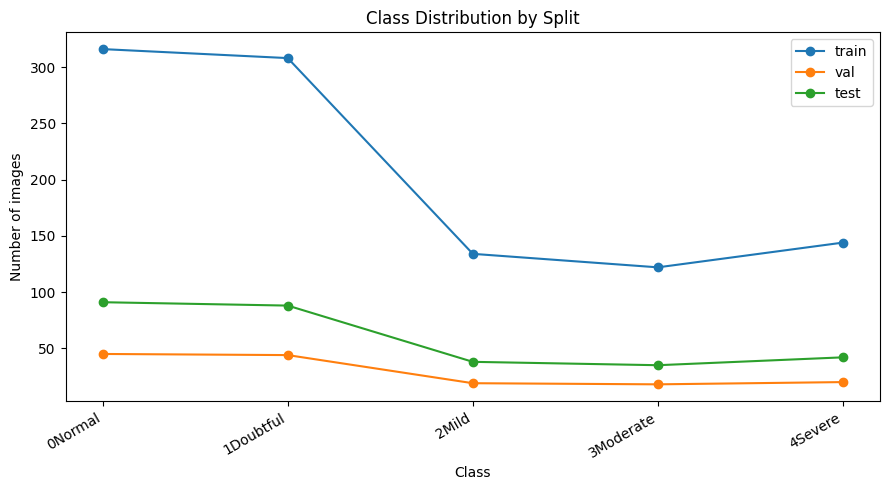

In [32]:
train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
val_dataset = datasets.ImageFolder(VAL_DIR, transform=val_transform)
test_dataset = datasets.ImageFolder(TEST_DIR, transform=test_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG["BATCH_SIZE"],
    shuffle=True,
    num_workers=CONFIG["NUM_WORKERS"],
    pin_memory=torch.cuda.is_available(),
)
val_loader = DataLoader(
    val_dataset,
    batch_size=CONFIG["BATCH_SIZE"],
    shuffle=False,
    num_workers=CONFIG["NUM_WORKERS"],
    pin_memory=torch.cuda.is_available(),
)
test_loader = DataLoader(
    test_dataset,
    batch_size=CONFIG["BATCH_SIZE"],
    shuffle=False,
    num_workers=CONFIG["NUM_WORKERS"],
    pin_memory=torch.cuda.is_available(),
)

print("Train dataset size:", len(train_dataset))
print("Validation dataset size:", len(val_dataset))
print("Test dataset size:", len(test_dataset))
print("Class mapping:", train_dataset.class_to_idx)

class_names = train_dataset.classes
idx_to_class = {i: c for i, c in enumerate(class_names)}
print("Class names:", class_names)

def dataset_distribution(dataset, split_name):
    targets = np.array(dataset.targets)
    rows = []
    for class_idx, class_name in enumerate(dataset.classes):
        rows.append({
            "split": split_name,
            "class_idx": class_idx,
            "class_name": class_name,
            "count": int((targets == class_idx).sum())
        })
    return pd.DataFrame(rows)

dist_df = pd.concat([
    dataset_distribution(train_dataset, "train"),
    dataset_distribution(val_dataset, "val"),
    dataset_distribution(test_dataset, "test"),
], ignore_index=True)

display(dist_df)

plt.figure(figsize=(9, 5))
for split in ["train", "val", "test"]:
    temp = dist_df[dist_df["split"] == split]
    plt.plot(temp["class_name"], temp["count"], marker="o", label=split)
plt.title("Class Distribution by Split")
plt.xlabel("Class")
plt.ylabel("Number of images")
plt.xticks(rotation=30, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

## 7. Visualization

This section shows original image, transformed image, CLAHE preview, and a 4-crop example for explanation only. The 4-crop example is not used in this loss comparison training.

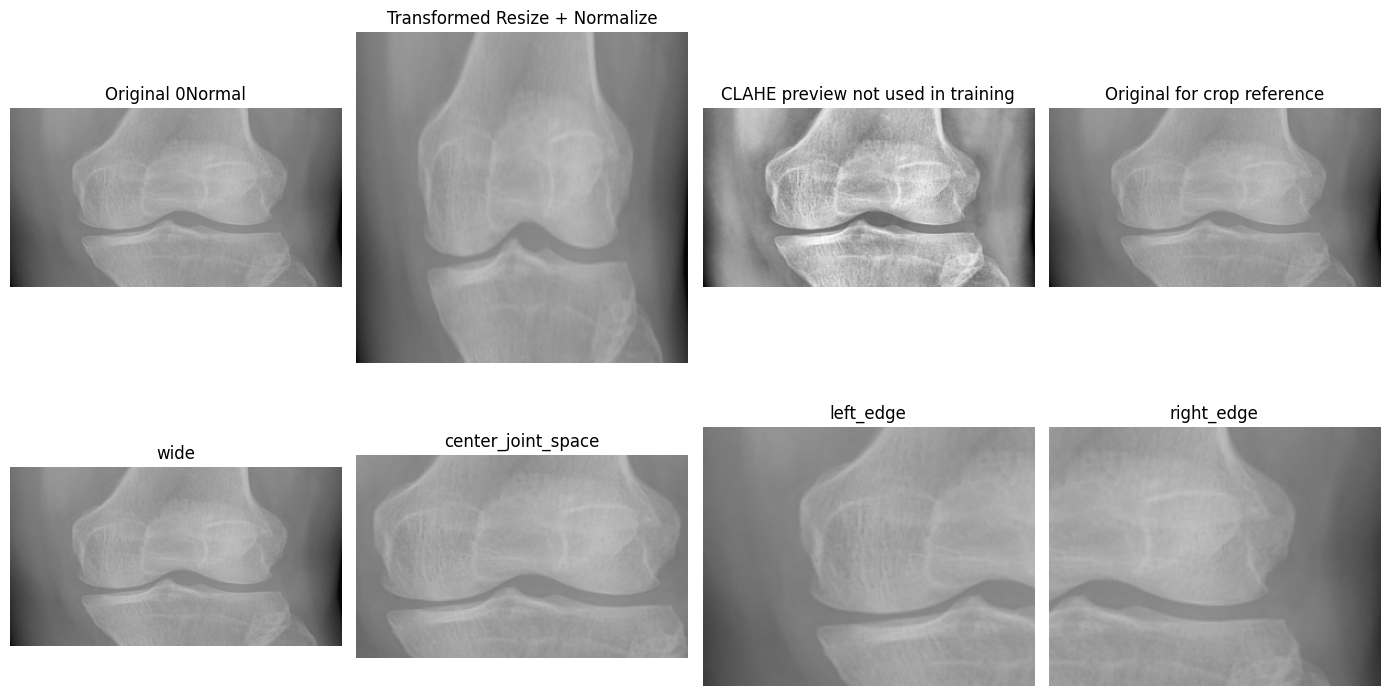

In [33]:
def denormalize_tensor(img_tensor, mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)):
    img = img_tensor.detach().cpu().clone()
    mean = torch.tensor(mean).view(3, 1, 1)
    std = torch.tensor(std).view(3, 1, 1)
    img = img * std + mean
    img = img.clamp(0, 1)
    return img.permute(1, 2, 0).numpy()


def apply_clahe_preview(pil_img):
    gray = np.array(pil_img.convert("L"))
    try:
        import cv2
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        enhanced = clahe.apply(gray)
    except Exception:
        from PIL import ImageOps
        enhanced = np.array(ImageOps.equalize(Image.fromarray(gray)))
    return enhanced


def make_crop_box(width, height, center_x_ratio, center_y_ratio, width_ratio, height_ratio):
    crop_w = max(1, int(width * width_ratio))
    crop_h = max(1, int(height * height_ratio))
    cx = int(width * center_x_ratio)
    cy = int(height * center_y_ratio)
    left = max(0, min(cx - crop_w // 2, width - crop_w))
    top = max(0, min(cy - crop_h // 2, height - crop_h))
    return (left, top, left + crop_w, top + crop_h)


def show_visualization_example(dataset, sample_idx=0):
    img_path, label = dataset.samples[sample_idx]
    original = Image.open(img_path).convert("RGB")
    transformed_tensor, _ = dataset[sample_idx]
    transformed_img = denormalize_tensor(transformed_tensor)
    clahe_img = apply_clahe_preview(original)

    w, h = original.size
    crop_boxes = {
        "wide": (0, 0, w, h),
        "center_joint_space": make_crop_box(w, h, 0.50, 0.50, 0.70, 0.80),
        "left_edge": make_crop_box(w, h, 0.30, 0.50, 0.55, 0.80),
        "right_edge": make_crop_box(w, h, 0.70, 0.50, 0.55, 0.80),
    }

    plt.figure(figsize=(14, 8))
    plt.subplot(2, 4, 1)
    plt.imshow(original, cmap="gray")
    plt.title(f"Original {idx_to_class[label]}")
    plt.axis("off")

    plt.subplot(2, 4, 2)
    plt.imshow(transformed_img)
    plt.title("Transformed Resize + Normalize")
    plt.axis("off")

    plt.subplot(2, 4, 3)
    plt.imshow(clahe_img, cmap="gray")
    plt.title("CLAHE preview not used in training")
    plt.axis("off")

    plt.subplot(2, 4, 4)
    plt.imshow(original, cmap="gray")
    plt.title("Original for crop reference")
    plt.axis("off")

    for plot_idx, (crop_name, box) in enumerate(crop_boxes.items(), start=5):
        crop = original.crop(box)
        plt.subplot(2, 4, plot_idx)
        plt.imshow(crop, cmap="gray")
        plt.title(crop_name)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_visualization_example(train_dataset, sample_idx=0)

## 8. Model Definition

This experiment uses a single-image DenseNet121 model. The model takes one full X-ray image and predicts one of five OA severity grades.

In [34]:
def build_densenet121(num_classes=5, pretrained=True):
    try:
        weights = models.DenseNet121_Weights.DEFAULT if pretrained else None
        model = models.densenet121(weights=weights)
    except Exception:
        model = models.densenet121(pretrained=pretrained)

    in_features = model.classifier.in_features
    model.classifier = nn.Linear(in_features, num_classes)
    return model

_demo_model = build_densenet121(num_classes=CONFIG["NUM_CLASSES"], pretrained=CONFIG["USE_PRETRAINED"])
print(_demo_model.classifier)
del _demo_model

Linear(in_features=1024, out_features=5, bias=True)


## 9. Loss Function

This section defines and prints the matrices for the ordinal-aware losses.

Compared losses:
1. **OrdinalCrossEntropyLoss**: CE + expected-grade MSE penalty.
2. **ChenOrdinalLoss**: Chen-style ordinal penalty matrix only.
3. **HybridChenOrdinalLoss**: CE + Chen-style ordinal penalty.

Ordinal-aware loss is used to reduce severe grading errors, because predicting a grade that is far away from the true grade should be penalized more than an adjacent mistake.

In [35]:
class OrdinalCrossEntropyLoss(nn.Module):
    def __init__(self, num_classes=5, alpha=0.2):
        super().__init__()
        self.num_classes = num_classes
        self.alpha = alpha
        self.ce_loss = nn.CrossEntropyLoss()
        class_values = torch.arange(num_classes, dtype=torch.float32)
        self.register_buffer("class_values", class_values)

    def forward(self, logits, targets):
        ce = self.ce_loss(logits, targets)
        probabilities = torch.softmax(logits, dim=1)
        expected_grade = torch.sum(probabilities * self.class_values.to(logits.device), dim=1)
        ordinal_mse = torch.mean((expected_grade - targets.float()) ** 2)
        return ce + self.alpha * ordinal_mse

    def get_distance_matrix(self):
        idx = torch.arange(self.num_classes, dtype=torch.float32)
        return (idx[:, None] - idx[None, :]).abs() ** 2


class ChenOrdinalLoss(nn.Module):
    def __init__(self, num_classes=5, penalty_distance=2, square_loss=True, normalize=False):
        super().__init__()
        self.num_classes = num_classes
        self.penalty_distance = penalty_distance
        self.square_loss = square_loss
        self.normalize = normalize
        penalty_matrix = self._create_penalty_matrix(num_classes, penalty_distance, normalize)
        self.register_buffer("penalty_matrix", penalty_matrix)

    def _create_penalty_matrix(self, num_classes, penalty_distance, normalize):
        class_indices = torch.arange(num_classes, dtype=torch.float32)
        distance_matrix = torch.abs(class_indices.unsqueeze(0) - class_indices.unsqueeze(1))
        penalty_matrix = distance_matrix * penalty_distance + 1.0
        penalty_matrix[distance_matrix == 0] = 0.0
        if normalize:
            max_value = penalty_matrix.max()
            if max_value > 0:
                penalty_matrix = penalty_matrix / max_value
        return penalty_matrix

    def forward(self, logits, targets):
        probabilities = torch.softmax(logits, dim=1)
        target_penalties = self.penalty_matrix.to(logits.device)[targets.long()]
        loss_per_sample = torch.sum(probabilities * target_penalties, dim=1)
        if self.square_loss:
            loss_per_sample = loss_per_sample ** 2
        return torch.mean(loss_per_sample)


class HybridChenOrdinalLoss(nn.Module):
    def __init__(self, num_classes=5, alpha=0.1, penalty_distance=2, square_loss=False, normalize=True):
        super().__init__()
        self.num_classes = num_classes
        self.alpha = alpha
        self.penalty_distance = penalty_distance
        self.square_loss = square_loss
        self.normalize = normalize
        self.ce_loss = nn.CrossEntropyLoss()
        penalty_matrix = self._create_penalty_matrix(num_classes, penalty_distance, normalize)
        self.register_buffer("penalty_matrix", penalty_matrix)

    def _create_penalty_matrix(self, num_classes, penalty_distance, normalize):
        class_indices = torch.arange(num_classes, dtype=torch.float32)
        distance_matrix = torch.abs(class_indices.unsqueeze(0) - class_indices.unsqueeze(1))
        penalty_matrix = distance_matrix * penalty_distance + 1.0
        penalty_matrix[distance_matrix == 0] = 0.0
        if normalize:
            max_value = penalty_matrix.max()
            if max_value > 0:
                penalty_matrix = penalty_matrix / max_value
        return penalty_matrix

    def forward(self, logits, targets):
        ce = self.ce_loss(logits, targets)
        probabilities = torch.softmax(logits, dim=1)
        target_penalties = self.penalty_matrix.to(logits.device)[targets.long()]
        penalty_per_sample = torch.sum(probabilities * target_penalties, dim=1)
        if self.square_loss:
            penalty_per_sample = penalty_per_sample ** 2
        ordinal_penalty = torch.mean(penalty_per_sample)
        return ce + self.alpha * ordinal_penalty


def build_criterion(loss_name):
    if loss_name == "OrdinalCrossEntropyLoss":
        return OrdinalCrossEntropyLoss(num_classes=CONFIG["NUM_CLASSES"], alpha=0.2)
    if loss_name == "ChenOrdinalLoss":
        return ChenOrdinalLoss(num_classes=CONFIG["NUM_CLASSES"], penalty_distance=2, square_loss=True, normalize=False)
    if loss_name == "HybridChenOrdinalLoss":
        return HybridChenOrdinalLoss(num_classes=CONFIG["NUM_CLASSES"], alpha=0.1, penalty_distance=2, square_loss=False, normalize=True)
    raise ValueError(f"Unknown loss: {loss_name}")

LOSS_EXPERIMENTS = [
    "OrdinalCrossEntropyLoss",
    "ChenOrdinalLoss",
    "HybridChenOrdinalLoss",
]

loss_matrix_records = {}
for loss_name in LOSS_EXPERIMENTS:
    criterion = build_criterion(loss_name)
    print("=" * 80)
    print("Loss:", loss_name)
    print(criterion)

    if isinstance(criterion, OrdinalCrossEntropyLoss):
        matrix = criterion.get_distance_matrix().cpu().numpy()
        print("Class values:", criterion.class_values.cpu().numpy())
        print("Implied squared ordinal distance matrix:")
        print(matrix)
    else:
        matrix = criterion.penalty_matrix.cpu().numpy()
        print("Penalty matrix:")
        print(matrix)
    loss_matrix_records[loss_name] = matrix.tolist()

Loss: OrdinalCrossEntropyLoss
OrdinalCrossEntropyLoss(
  (ce_loss): CrossEntropyLoss()
)
Class values: [0. 1. 2. 3. 4.]
Implied squared ordinal distance matrix:
[[ 0.  1.  4.  9. 16.]
 [ 1.  0.  1.  4.  9.]
 [ 4.  1.  0.  1.  4.]
 [ 9.  4.  1.  0.  1.]
 [16.  9.  4.  1.  0.]]
Loss: ChenOrdinalLoss
ChenOrdinalLoss()
Penalty matrix:
[[0. 3. 5. 7. 9.]
 [3. 0. 3. 5. 7.]
 [5. 3. 0. 3. 5.]
 [7. 5. 3. 0. 3.]
 [9. 7. 5. 3. 0.]]
Loss: HybridChenOrdinalLoss
HybridChenOrdinalLoss(
  (ce_loss): CrossEntropyLoss()
)
Penalty matrix:
[[0.         0.33333334 0.5555556  0.7777778  1.        ]
 [0.33333334 0.         0.33333334 0.5555556  0.7777778 ]
 [0.5555556  0.33333334 0.         0.33333334 0.5555556 ]
 [0.7777778  0.5555556  0.33333334 0.         0.33333334]
 [1.         0.7777778  0.5555556  0.33333334 0.        ]]


## 10. Optimizer & Scheduler

In [36]:
def build_optimizer_and_scheduler(model):
    optimizer = torch.optim.AdamW(
       model.parameters(),
       lr=CONFIG["LR"],
       weight_decay=CONFIG["WEIGHT_DECAY"]
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=CONFIG["EPOCHS"]
    )
    return optimizer, scheduler

print("Optimizer: AdamW")
print("Scheduler: CosineAnnealingLR")

Optimizer: AdamW
Scheduler: CosineAnnealingLR


## 11. Training Loop

In [37]:
def compute_metrics(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    diff = np.abs(y_true - y_pred)
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "weighted_f1": float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
        "qwk": float(cohen_kappa_score(y_true, y_pred, weights="quadratic")),
        "mae": float(np.mean(diff)),
        "total_errors": int(np.sum(diff > 0)),
        "adjacent_errors": int(np.sum(diff == 1)),
        "distant_errors": int(np.sum(diff >= 2)),
    }


def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    y_true, y_pred = [], []
    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * labels.size(0)
        preds = logits.argmax(dim=1)
        y_true.extend(labels.detach().cpu().numpy())
        y_pred.extend(preds.detach().cpu().numpy())
    metrics = compute_metrics(y_true, y_pred)
    metrics["loss"] = float(running_loss / len(loader.dataset))
    return metrics


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    y_true, y_pred = [], []
    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        logits = model(images)
        loss = criterion(logits, labels)
        running_loss += loss.item() * labels.size(0)
        preds = logits.argmax(dim=1)
        y_true.extend(labels.detach().cpu().numpy())
        y_pred.extend(preds.detach().cpu().numpy())
    metrics = compute_metrics(y_true, y_pred)
    metrics["loss"] = float(running_loss / len(loader.dataset))
    return metrics, np.array(y_true), np.array(y_pred)


def train_single_loss_experiment(loss_name):
    print("=" * 90)
    print("Starting loss experiment:", loss_name)
    print("=" * 90)
    set_seed(CONFIG["SEED"])
    model = build_densenet121(CONFIG["NUM_CLASSES"], CONFIG["USE_PRETRAINED"]).to(device)
    criterion = build_criterion(loss_name).to(device)
    optimizer, scheduler = build_optimizer_and_scheduler(model)
    model_path = MODELS_DIR / f"{loss_name}_best.pth"
    history = []
    best_val_qwk = -999
    best_epoch = 0
    patience_counter = 0

    for epoch in range(1, CONFIG["EPOCHS"] + 1):
        train_metrics = train_one_epoch(model, train_loader, criterion, optimizer)
        val_metrics, _, _ = evaluate(model, val_loader, criterion)
        scheduler.step()
        row = {
            "epoch": epoch,
            "loss_name": loss_name,
            "train_loss": train_metrics["loss"],
            "val_loss": val_metrics["loss"],
            "train_accuracy": train_metrics["accuracy"],
            "val_accuracy": val_metrics["accuracy"],
            "train_macro_f1": train_metrics["macro_f1"],
            "val_macro_f1": val_metrics["macro_f1"],
            "train_qwk": train_metrics["qwk"],
            "val_qwk": val_metrics["qwk"],
            "train_mae": train_metrics["mae"],
            "val_mae": val_metrics["mae"],
            "val_adjacent_errors": val_metrics["adjacent_errors"],
            "val_distant_errors": val_metrics["distant_errors"],
        }
        history.append(row)
        print(
            f"[{loss_name}] Epoch {epoch:02d}/{CONFIG['EPOCHS']} | "
            f"train_loss={train_metrics['loss']:.4f} val_loss={val_metrics['loss']:.4f} | "
            f"val_acc={val_metrics['accuracy']:.4f} val_qwk={val_metrics['qwk']:.4f} "
            f"val_mae={val_metrics['mae']:.4f} val_macro_f1={val_metrics['macro_f1']:.4f}"
        )
        if val_metrics["qwk"] > best_val_qwk:
            best_val_qwk = val_metrics["qwk"]
            best_epoch = epoch
            patience_counter = 0
            torch.save(model.state_dict(), model_path)
            print(f"  Saved best model for {loss_name} at epoch {epoch} with val_qwk={best_val_qwk:.4f}")
        else:
            patience_counter += 1
        if patience_counter >= CONFIG["PATIENCE"]:
            print(f"  Early stopping at epoch {epoch}")
            break

    history_df = pd.DataFrame(history)
    history_path = RESULTS_DIR / f"{loss_name}_history.csv"
    history_df.to_csv(history_path, index=False)
    del model
    torch.cuda.empty_cache()
    return {
        "loss_name": loss_name,
        "model_path": str(model_path),
        "history_path": str(history_path),
        "best_epoch": int(best_epoch),
        "best_val_qwk": float(best_val_qwk),
        "history_df": history_df,
    }

print("Training utilities are ready.")

Training utilities are ready.


In [38]:
all_experiment_records = []
for loss_name in LOSS_EXPERIMENTS:
    record = train_single_loss_experiment(loss_name)
    all_experiment_records.append(record)
print("All loss experiments completed.")

Starting loss experiment: OrdinalCrossEntropyLoss
[OrdinalCrossEntropyLoss] Epoch 01/30 | train_loss=1.2414 val_loss=0.9079 | val_acc=0.6575 val_qwk=0.7895 val_mae=0.4932 val_macro_f1=0.5921
  Saved best model for OrdinalCrossEntropyLoss at epoch 1 with val_qwk=0.7895
[OrdinalCrossEntropyLoss] Epoch 02/30 | train_loss=0.6961 val_loss=0.8417 | val_acc=0.6849 val_qwk=0.8470 val_mae=0.3904 val_macro_f1=0.6360
  Saved best model for OrdinalCrossEntropyLoss at epoch 2 with val_qwk=0.8470
[OrdinalCrossEntropyLoss] Epoch 03/30 | train_loss=0.3619 val_loss=0.6378 | val_acc=0.7808 val_qwk=0.9037 val_mae=0.2671 val_macro_f1=0.7440
  Saved best model for OrdinalCrossEntropyLoss at epoch 3 with val_qwk=0.9037
[OrdinalCrossEntropyLoss] Epoch 04/30 | train_loss=0.2470 val_loss=0.7004 | val_acc=0.7671 val_qwk=0.8571 val_mae=0.3219 val_macro_f1=0.7427
[OrdinalCrossEntropyLoss] Epoch 05/30 | train_loss=0.1674 val_loss=0.6794 | val_acc=0.8014 val_qwk=0.9060 val_mae=0.2466 val_macro_f1=0.7603
  Saved bes

## 12. Validation Section

,loss_name,best_epoch,best_val_qwk,best_val_accuracy,best_val_macro_f1,best_val_mae,best_val_adjacent_errors,best_val_distant_errors
1,ChenOrdinalLoss,7,0.941714,0.815068,0.788227,0.198630,25,2
2,HybridChenOrdinalLoss,5,0.909117,0.794521,0.770572,0.253425,24,6
0,OrdinalCrossEntropyLoss,5,0.906000,0.801370,0.760345,0.246575,24,5


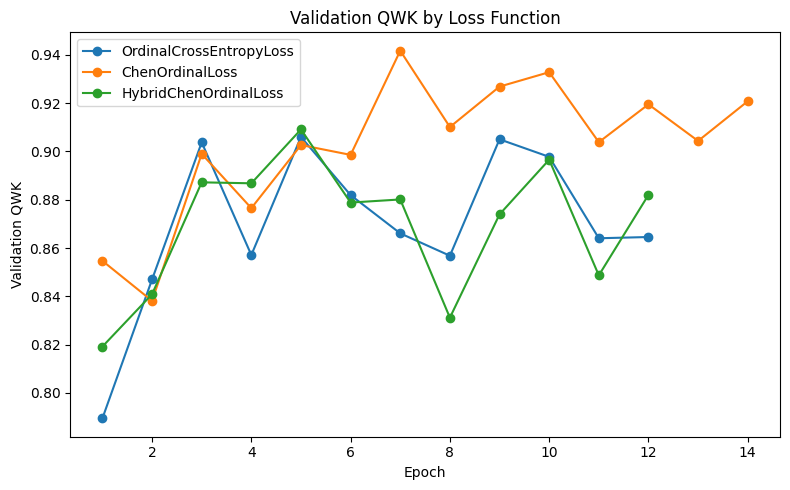

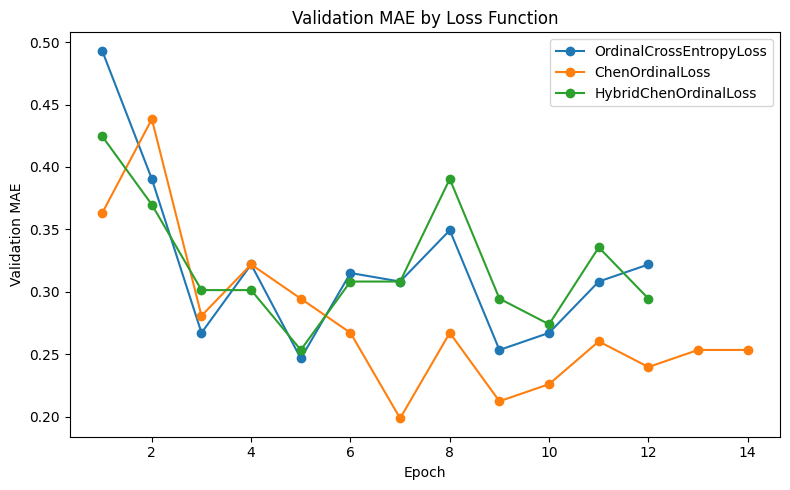

In [39]:
val_summary_rows = []
for record in all_experiment_records:
    hist = record["history_df"]
    best_row_val = hist.loc[hist["val_qwk"].idxmax()].to_dict()
    val_summary_rows.append({
        "loss_name": record["loss_name"],
        "best_epoch": record["best_epoch"],
        "best_val_qwk": record["best_val_qwk"],
        "best_val_accuracy": best_row_val["val_accuracy"],
        "best_val_macro_f1": best_row_val["val_macro_f1"],
        "best_val_mae": best_row_val["val_mae"],
        "best_val_adjacent_errors": best_row_val["val_adjacent_errors"],
        "best_val_distant_errors": best_row_val["val_distant_errors"],
    })
val_summary_df = pd.DataFrame(val_summary_rows).sort_values("best_val_qwk", ascending=False)
display(val_summary_df)

plt.figure(figsize=(8, 5))
for record in all_experiment_records:
    hist = record["history_df"]
    plt.plot(hist["epoch"], hist["val_qwk"], marker="o", label=record["loss_name"])
plt.title("Validation QWK by Loss Function")
plt.xlabel("Epoch")
plt.ylabel("Validation QWK")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
for record in all_experiment_records:
    hist = record["history_df"]
    plt.plot(hist["epoch"], hist["val_mae"], marker="o", label=record["loss_name"])
plt.title("Validation MAE by Loss Function")
plt.xlabel("Epoch")
plt.ylabel("Validation MAE")
plt.legend()
plt.tight_layout()
plt.show()

## 13. Test Evaluation

In [40]:
def load_best_model_for_loss(loss_name, model_path):
    model = build_densenet121(CONFIG["NUM_CLASSES"], CONFIG["USE_PRETRAINED"]).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()
    return model

test_results = []
test_predictions = {}
for record in all_experiment_records:
    loss_name = record["loss_name"]
    model = load_best_model_for_loss(loss_name, record["model_path"])
    criterion = build_criterion(loss_name).to(device)
    test_metrics, test_true, test_pred = evaluate(model, test_loader, criterion)
    test_predictions[loss_name] = {"y_true": test_true, "y_pred": test_pred}
    row = {"loss_name": loss_name, "best_epoch": record["best_epoch"], "best_val_qwk": record["best_val_qwk"], **test_metrics}
    test_results.append(row)
    print("=" * 80)
    print("Test results for:", loss_name)
    for k, v in test_metrics.items():
        print(f"{k}: {v}")
    del model
    torch.cuda.empty_cache()

test_results_df = pd.DataFrame(test_results).sort_values("qwk", ascending=False)
display(test_results_df)
test_results_df.to_csv(RESULTS_DIR / "loss_comparison_test_results.csv", index=False)

Test results for: OrdinalCrossEntropyLoss
accuracy: 0.7687074829931972
macro_f1: 0.7526563232948682
weighted_f1: 0.7648637832895747
qwk: 0.8315032161692528
mae: 0.3401360544217687
total_errors: 68
adjacent_errors: 48
distant_errors: 20
loss: 0.76097821672352
Test results for: ChenOrdinalLoss
accuracy: 0.7380952380952381
macro_f1: 0.7253046667299512
weighted_f1: 0.7373217092077153
qwk: 0.8260815981957444
mae: 0.3673469387755102
total_errors: 77
adjacent_errors: 57
distant_errors: 20
loss: 3.5585138213877774
Test results for: HybridChenOrdinalLoss
accuracy: 0.7687074829931972
macro_f1: 0.7521136525999277
weighted_f1: 0.767677969530874
qwk: 0.8604070943654412
mae: 0.3231292517006803
total_errors: 68
adjacent_errors: 47
distant_errors: 21
loss: 0.7040732441102566


,loss_name,best_epoch,best_val_qwk,accuracy,macro_f1,weighted_f1,qwk,mae,total_errors,adjacent_errors,distant_errors,loss
2,HybridChenOrdinalLoss,5,0.909117,0.768707,0.752114,0.767678,0.860407,0.323129,68,47,21,0.704073
0,OrdinalCrossEntropyLoss,5,0.906000,0.768707,0.752656,0.764864,0.831503,0.340136,68,48,20,0.760978
1,ChenOrdinalLoss,7,0.941714,0.738095,0.725305,0.737322,0.826082,0.367347,77,57,20,3.558514


## 13.1 Per-class Recall and F1

In [41]:
per_class_reports = {}
for row in test_results:
    loss_name = row["loss_name"]
    y_true = test_predictions[loss_name]["y_true"]
    y_pred = test_predictions[loss_name]["y_pred"]
    print("=" * 80)
    print("Classification report:", loss_name)
    report_text = classification_report(y_true, y_pred, target_names=class_names, digits=4, zero_division=0)
    print(report_text)
    report_dict = classification_report(y_true, y_pred, target_names=class_names, output_dict=True, zero_division=0)
    per_class_reports[loss_name] = report_dict
    per_class_df = pd.DataFrame(report_dict).T
    display(per_class_df)
    per_class_df.to_csv(RESULTS_DIR / f"{loss_name}_classification_report.csv")

Classification report: OrdinalCrossEntropyLoss
              precision    recall  f1-score   support

     0Normal     0.8125    0.8571    0.8342        91
   1Doubtful     0.6827    0.8068    0.7396        88
       2Mild     0.7200    0.4737    0.5714        38
   3Moderate     0.8286    0.8286    0.8286        35
     4Severe     0.8824    0.7143    0.7895        42

    accuracy                         0.7687       294
   macro avg     0.7852    0.7361    0.7527       294
weighted avg     0.7736    0.7687    0.7649       294



,precision,recall,f1-score,support
0Normal,0.812500,0.857143,0.834225,91.000000
1Doubtful,0.682692,0.806818,0.739583,88.000000
2Mild,0.720000,0.473684,0.571429,38.000000
3Moderate,0.828571,0.828571,0.828571,35.000000
4Severe,0.882353,0.714286,0.789474,42.000000
accuracy,0.768707,0.768707,0.768707,0.768707
macro avg,0.785223,0.736100,0.752656,294.000000
weighted avg,0.773582,0.768707,0.764864,294.000000


Classification report: ChenOrdinalLoss
              precision    recall  f1-score   support

     0Normal     0.8172    0.8352    0.8261        91
   1Doubtful     0.6500    0.7386    0.6915        88
       2Mild     0.5455    0.4737    0.5070        38
   3Moderate     0.8286    0.8286    0.8286        35
     4Severe     0.8788    0.6905    0.7733        42

    accuracy                         0.7381       294
   macro avg     0.7440    0.7133    0.7253       294
weighted avg     0.7422    0.7381    0.7373       294



,precision,recall,f1-score,support
0Normal,0.817204,0.835165,0.826087,91.000000
1Doubtful,0.650000,0.738636,0.691489,88.000000
2Mild,0.545455,0.473684,0.507042,38.000000
3Moderate,0.828571,0.828571,0.828571,35.000000
4Severe,0.878788,0.690476,0.773333,42.000000
accuracy,0.738095,0.738095,0.738095,0.738095
macro avg,0.744004,0.713307,0.725305,294.000000
weighted avg,0.742184,0.738095,0.737322,294.000000


Classification report: HybridChenOrdinalLoss
              precision    recall  f1-score   support

     0Normal     0.8659    0.7802    0.8208        91
   1Doubtful     0.7396    0.8068    0.7717        88
       2Mild     0.6364    0.5526    0.5915        38
   3Moderate     0.7500    0.8571    0.8000        35
     4Severe     0.7674    0.7857    0.7765        42

    accuracy                         0.7687       294
   macro avg     0.7518    0.7565    0.7521       294
weighted avg     0.7705    0.7687    0.7677       294



,precision,recall,f1-score,support
0Normal,0.865854,0.780220,0.820809,91.000000
1Doubtful,0.739583,0.806818,0.771739,88.000000
2Mild,0.636364,0.552632,0.591549,38.000000
3Moderate,0.750000,0.857143,0.800000,35.000000
4Severe,0.767442,0.785714,0.776471,42.000000
accuracy,0.768707,0.768707,0.768707,0.768707
macro avg,0.751848,0.756505,0.752114,294.000000
weighted avg,0.770546,0.768707,0.767678,294.000000


## 14. Confusion Matrix

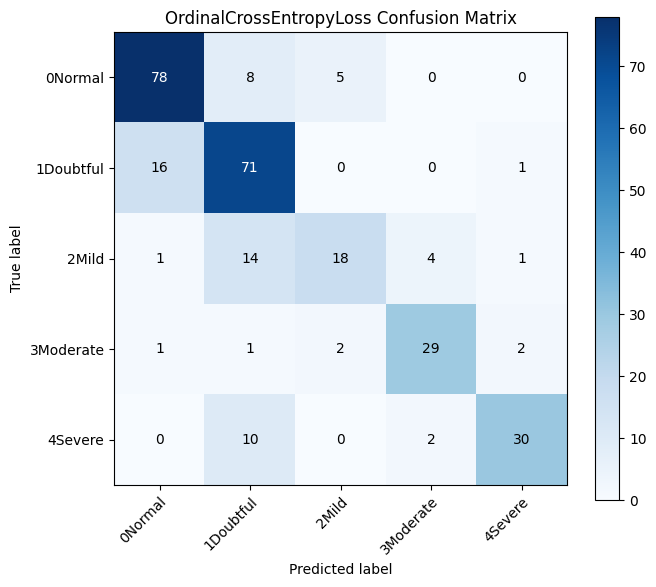

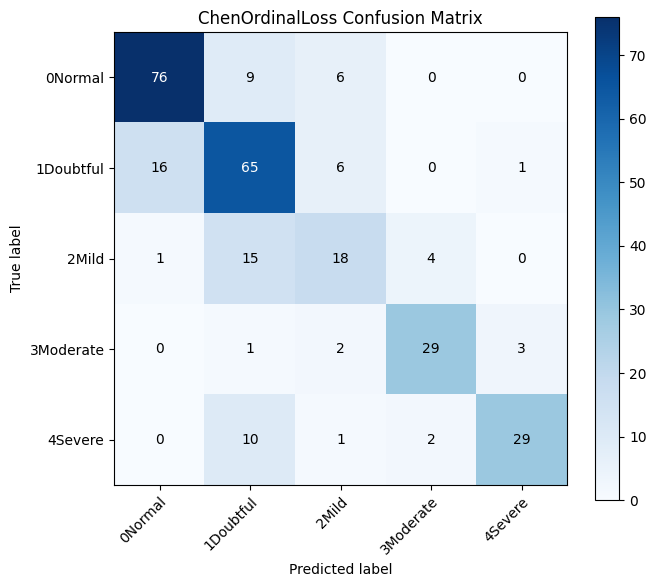

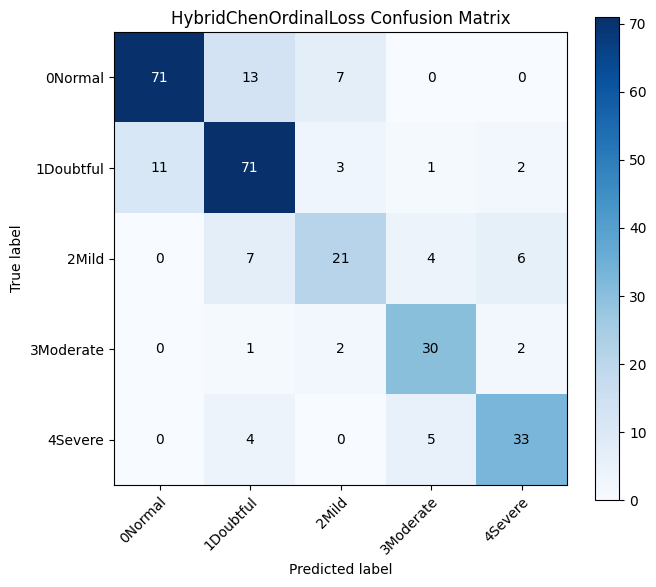

In [42]:
def plot_confusion_matrix(cm, labels, title, save_path=None):
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
    ax.figure.colorbar(im, ax=ax)
    ax.set(
        xticks=np.arange(cm.shape[1]),
        yticks=np.arange(cm.shape[0]),
        xticklabels=labels,
        yticklabels=labels,
        ylabel="True label",
        xlabel="Predicted label",
        title=title,
    )
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    threshold = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], "d"), ha="center", va="center", color="white" if cm[i, j] > threshold else "black")
    fig.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()

for row in test_results:
    loss_name = row["loss_name"]
    y_true = test_predictions[loss_name]["y_true"]
    y_pred = test_predictions[loss_name]["y_pred"]
    cm = confusion_matrix(y_true, y_pred)
    np.save(RESULTS_DIR / f"{loss_name}_confusion_matrix.npy", cm)
    plot_confusion_matrix(cm, class_names, f"{loss_name} Confusion Matrix", FIGURES_DIR / f"{loss_name}_confusion_matrix.png")

## 15. Error Analysis

Adjacent errors mean the predicted grade differs from the true grade by exactly 1. Distant errors mean the predicted grade differs by 2 or more.

,loss_name,correct,adjacent_errors,distant_errors,total_errors,mean_absolute_error
0,OrdinalCrossEntropyLoss,226,48,20,68,0.340136
1,ChenOrdinalLoss,217,57,20,77,0.367347
2,HybridChenOrdinalLoss,226,47,21,68,0.323129


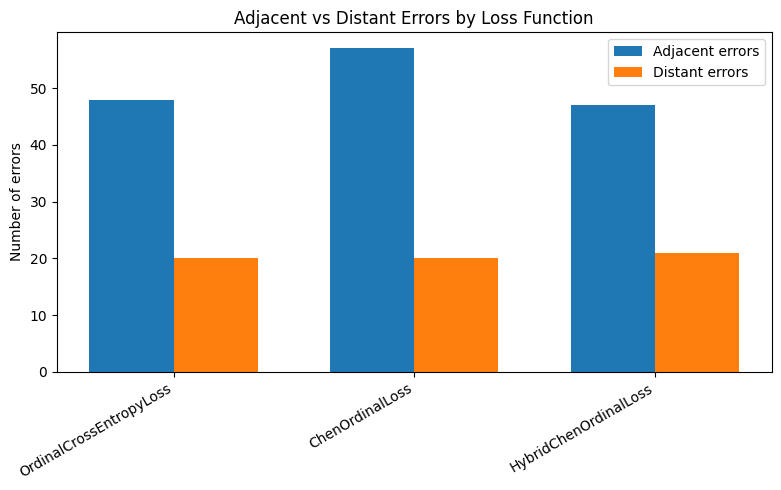

In [43]:
error_rows = []
for row in test_results:
    loss_name = row["loss_name"]
    y_true = test_predictions[loss_name]["y_true"]
    y_pred = test_predictions[loss_name]["y_pred"]
    diff = np.abs(y_true - y_pred)
    error_rows.append({
        "loss_name": loss_name,
        "correct": int(np.sum(diff == 0)),
        "adjacent_errors": int(np.sum(diff == 1)),
        "distant_errors": int(np.sum(diff >= 2)),
        "total_errors": int(np.sum(diff > 0)),
        "mean_absolute_error": float(np.mean(diff)),
    })
error_df = pd.DataFrame(error_rows).sort_values("distant_errors")
display(error_df)
error_df.to_csv(RESULTS_DIR / "loss_comparison_error_analysis.csv", index=False)

plt.figure(figsize=(8, 5))
x = np.arange(len(error_df))
width = 0.35
plt.bar(x - width/2, error_df["adjacent_errors"], width, label="Adjacent errors")
plt.bar(x + width/2, error_df["distant_errors"], width, label="Distant errors")
plt.xticks(x, error_df["loss_name"], rotation=30, ha="right")
plt.ylabel("Number of errors")
plt.title("Adjacent vs Distant Errors by Loss Function")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "adjacent_vs_distant_errors.png", dpi=200, bbox_inches="tight")
plt.show()

## 16. Grad-CAM

Grad-CAM is shown for one correctly classified image and one misclassified image using the best-performing loss function based on test QWK.

Best loss for Grad-CAM: HybridChenOrdinalLoss


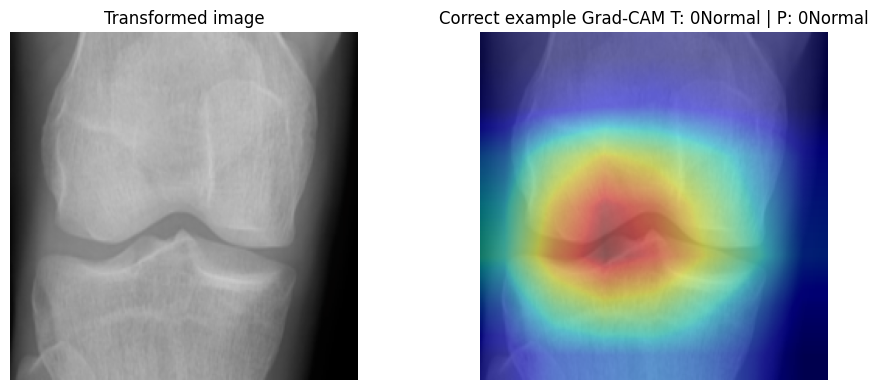

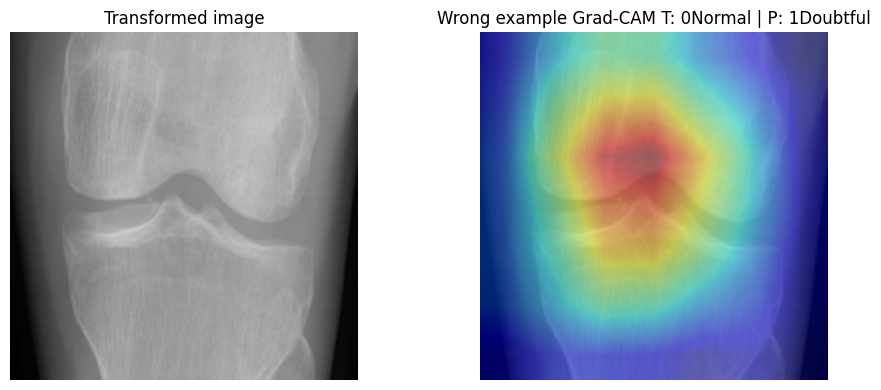

In [45]:
best_loss_name = test_results_df.iloc[0]["loss_name"]
best_model_path = [r for r in all_experiment_records if r["loss_name"] == best_loss_name][0]["model_path"]
best_model = load_best_model_for_loss(best_loss_name, best_model_path)
print("Best loss for Grad-CAM:", best_loss_name)

class DenseNetGradCAM:
    def __init__(self, model):
        self.model = model
        self.model.eval()
        self.activations = None
        self.gradients = None
        self.target_layer = self.model.features.denseblock4
        self.forward_handle = self.target_layer.register_forward_hook(self._save_activation)
        self.backward_handle = self.target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, target_class=None):
        self.model.zero_grad(set_to_none=True)
        logits = self.model(input_tensor)
        if target_class is None:
            target_class = logits.argmax(dim=1).item()
        score = logits[:, target_class].sum()
        score.backward()
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = torch.relu(cam)
        cam = torch.nn.functional.interpolate(cam, size=input_tensor.shape[2:], mode="bilinear", align_corners=False)
        cam = cam.squeeze().detach().cpu().numpy()
        cam = cam - cam.min()
        if cam.max() > 0:
            cam = cam / cam.max()
        return cam, logits.detach()

    def close(self):
        self.forward_handle.remove()
        self.backward_handle.remove()


def show_gradcam_for_index(model, dataset, idx, y_true, y_pred, title_prefix):
    img_tensor, label = dataset[idx]
    input_tensor = img_tensor.unsqueeze(0).to(device)
    gradcam = DenseNetGradCAM(model)
    cam, logits = gradcam.generate(input_tensor, target_class=int(y_pred[idx]))
    gradcam.close()
    img_np = denormalize_tensor(img_tensor)
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(img_np)
    plt.axis("off")
    plt.title("Transformed image")
    plt.subplot(1, 2, 2)
    plt.imshow(img_np)
    plt.imshow(cam, cmap="jet", alpha=0.45)
    plt.axis("off")
    plt.title(f"{title_prefix} T: {class_names[int(y_true[idx])]} | P: {class_names[int(y_pred[idx])]}")
    plt.tight_layout()
    plt.show()

best_true = test_predictions[best_loss_name]["y_true"]
best_pred = test_predictions[best_loss_name]["y_pred"]
correct_indices = np.where(best_true == best_pred)[0]
wrong_indices = np.where(best_true != best_pred)[0]

if len(correct_indices) > 0:
    show_gradcam_for_index(best_model, test_dataset, int(correct_indices[0]), best_true, best_pred, "Correct example Grad-CAM")
if len(wrong_indices) > 0:
    show_gradcam_for_index(best_model, test_dataset, int(wrong_indices[0]), best_true, best_pred, "Wrong example Grad-CAM")

## 17. Final Summary

# Experiment Conclusion

This experiment compares three ordinal-aware loss functions using the same single-image DenseNet121 model. The purpose is to test whether changing the loss function alone improves ordinal grading performance before introducing 4-crop input or class imbalance handling.

In [47]:
print("Final test summary sorted by QWK:")
display(test_results_df)
print("Error analysis summary:")
display(error_df)

best_row = test_results_df.iloc[0].to_dict()
print("Best loss function:", best_row["loss_name"])
print("Best test QWK:", best_row["qwk"])
print("Best test accuracy:", best_row["accuracy"])
print("Best test MAE:", best_row["mae"])
print("Best test distant errors:", best_row["distant_errors"])

summary_text = "".join([
    "Experiment Conclusion",
    "---------------------",
    "Model: Single-image DenseNet121",
    "Compared losses: OrdinalCrossEntropyLoss, ChenOrdinalLoss, HybridChenOrdinalLoss",
    f"Best loss: {best_row['loss_name']}",
    f"Best test accuracy: {best_row['accuracy']:.4f}",
    f"Best test macro F1: {best_row['macro_f1']:.4f}",
    f"Best test weighted F1: {best_row['weighted_f1']:.4f}",
    f"Best test QWK: {best_row['qwk']:.4f}",
    f"Best test MAE: {best_row['mae']:.4f}",
    f"Best test adjacent errors: {best_row['adjacent_errors']}",
    f"Best test distant errors: {best_row['distant_errors']}",
    "",
    "Interpretation:",
    "Ordinal-aware losses are evaluated because knee OA grading has an ordered severity structure.",
    "The best loss should not only improve accuracy, but also reduce distant grading errors.",
])
print(summary_text)

Final test summary sorted by QWK:


,loss_name,best_epoch,best_val_qwk,accuracy,macro_f1,weighted_f1,qwk,mae,total_errors,adjacent_errors,distant_errors,loss
2,HybridChenOrdinalLoss,5,0.909117,0.768707,0.752114,0.767678,0.860407,0.323129,68,47,21,0.704073
0,OrdinalCrossEntropyLoss,5,0.906000,0.768707,0.752656,0.764864,0.831503,0.340136,68,48,20,0.760978
1,ChenOrdinalLoss,7,0.941714,0.738095,0.725305,0.737322,0.826082,0.367347,77,57,20,3.558514


Error analysis summary:


,loss_name,correct,adjacent_errors,distant_errors,total_errors,mean_absolute_error
0,OrdinalCrossEntropyLoss,226,48,20,68,0.340136
1,ChenOrdinalLoss,217,57,20,77,0.367347
2,HybridChenOrdinalLoss,226,47,21,68,0.323129


Best loss function: HybridChenOrdinalLoss
Best test QWK: 0.8604070943654412
Best test accuracy: 0.7687074829931972
Best test MAE: 0.3231292517006803
Best test distant errors: 21
Experiment Conclusion---------------------Model: Single-image DenseNet121Compared losses: OrdinalCrossEntropyLoss, ChenOrdinalLoss, HybridChenOrdinalLossBest loss: HybridChenOrdinalLossBest test accuracy: 0.7687Best test macro F1: 0.7521Best test weighted F1: 0.7677Best test QWK: 0.8604Best test MAE: 0.3231Best test adjacent errors: 47Best test distant errors: 21Interpretation:Ordinal-aware losses are evaluated because knee OA grading has an ordered severity structure.The best loss should not only improve accuracy, but also reduce distant grading errors.


## 18. Save Results

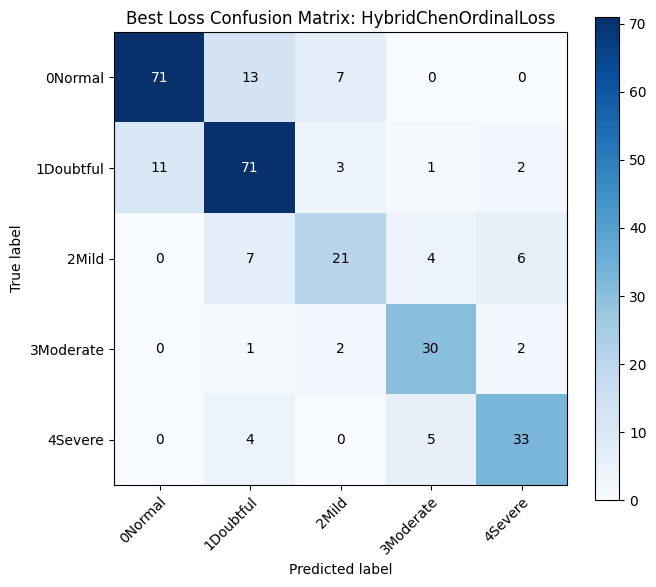

Saved metrics to: /kaggle/working/exp02_single_image_densenet121_loss_comparison/results/metrics.json
Saved confusion matrix figure to: /kaggle/working/exp02_single_image_densenet121_loss_comparison/figures/confusion_matrix.png
Saved all outputs under: /kaggle/working/exp02_single_image_densenet121_loss_comparison


In [48]:
metrics_json = {
    "config": CONFIG,
    "loss_matrices": loss_matrix_records,
    "validation_summary": val_summary_df.to_dict(orient="records"),
    "test_results": test_results_df.to_dict(orient="records"),
    "error_analysis": error_df.to_dict(orient="records"),
    "best_loss_name": str(best_row["loss_name"]),
    "best_metrics": {k: (float(v) if isinstance(v, (np.floating, float)) else int(v) if isinstance(v, (np.integer, int)) else str(v)) for k, v in best_row.items()},
}

with open(RESULTS_DIR / "metrics.json", "w") as f:
    json.dump(metrics_json, f, indent=4)
with open(RESULTS_DIR / "experiment_summary.txt", "w") as f:
    f.write(summary_text)
val_summary_df.to_csv(RESULTS_DIR / "validation_summary.csv", index=False)
test_results_df.to_csv(RESULTS_DIR / "test_summary.csv", index=False)
error_df.to_csv(RESULTS_DIR / "error_summary.csv", index=False)

best_y_true = test_predictions[best_loss_name]["y_true"]
best_y_pred = test_predictions[best_loss_name]["y_pred"]
best_cm = confusion_matrix(best_y_true, best_y_pred)
np.save(RESULTS_DIR / "confusion_matrix.npy", best_cm)
plot_confusion_matrix(
    best_cm,
    labels=class_names,
    title=f"Best Loss Confusion Matrix: {best_loss_name}",
    save_path=FIGURES_DIR / "confusion_matrix.png"
)

print("Saved metrics to:", RESULTS_DIR / "metrics.json")
print("Saved confusion matrix figure to:", FIGURES_DIR / "confusion_matrix.png")
print("Saved all outputs under:", SAVE_DIR)